## Dataset Statistics

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import measure
import random
import os

In [5]:
PROJECT_FOLDER = r"C:\Users\Alberto\Desktop\Steel-Defect-Detection"
IMG_NUM = 12568

In [6]:
df = pd.read_csv(f"{PROJECT_FOLDER}/data/raw/train.csv")
print(df.head())

         ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...
3  000f6bf48.jpg        4  131973 1 132228 4 132483 6 132738 8 132993 11 ...
4  0014fce06.jpg        3  229501 11 229741 33 229981 55 230221 77 230468...


### Images with defects ratio

In [7]:
defects_num = len(df["ImageId"])
img_with_defects_num = len(set(df["ImageId"]))

print(f"Number of images with defects: {img_with_defects_num}")
print(f"Number of images without defects: {IMG_NUM - img_with_defects_num}")
print(f"Average number of defects of different type per image (with defects): {defects_num / img_with_defects_num}")

Number of images with defects: 6666
Number of images without defects: 5902
Average number of defects of different type per image (with defects): 1.0643564356435644


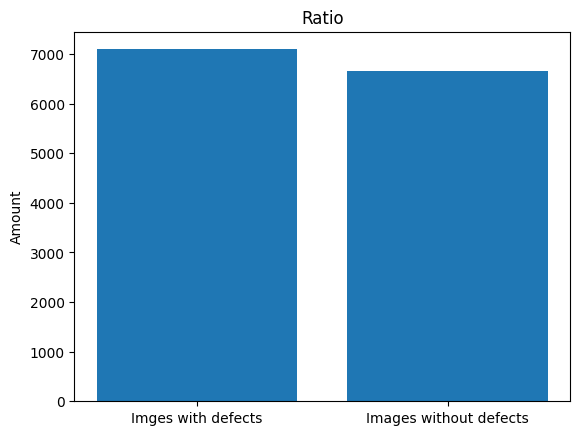

In [8]:
plt.bar(["Imges with defects", "Images without defects"],[defects_num, img_with_defects_num])
plt.ylabel("Amount")
plt.title("Ratio")
plt.show()

### Defects ratio

In [9]:
defects_ratio = df["ClassId"].value_counts().sort_index()
defects_ratio

ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64

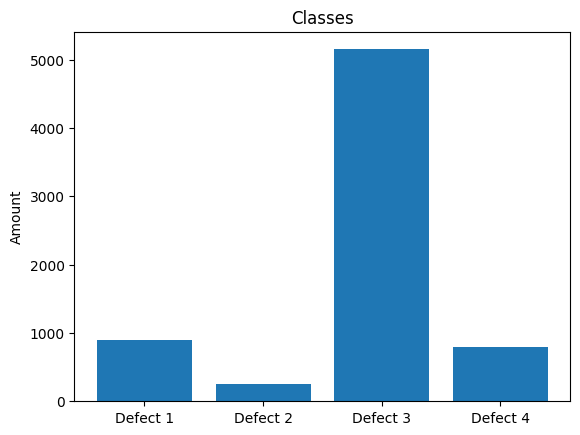

In [10]:
x_labels = ["Defect 1", "Defect 2", "Defect 3", "Defect 4"]

plt.bar(x_labels, defects_ratio)
plt.title("Classes")
plt.ylabel("Amount")
plt.show()

### Images visualization

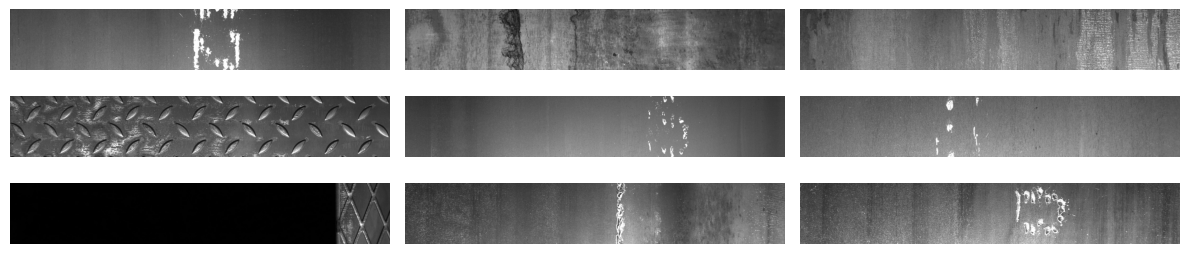

In [14]:
DEFECT = 0   # 0: no defect


if DEFECT != 0:
    filtered_df = df[df["ClassId"] == DEFECT]

else:
    all_images_list = os.listdir(f"{PROJECT_FOLDER}/data/raw/train_images")
    all_images_list = pd.DataFrame(all_images_list, columns=["ImageId"])
    filtered_df = all_images_list[~all_images_list["ImageId"].isin(df["ImageId"])]

image_paths = set(filtered_df["ImageId"])
selected = random.sample(list(image_paths), 9)

fig, axes = plt.subplots(3,3, figsize=(12,3))
for ax, img_path in zip(axes.flatten(), selected):
    img = Image.open(f"{PROJECT_FOLDER}/data/raw/train_images/{img_path}")
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Defects visualization

In [15]:
import numpy as np

def rle_to_mask(rle, shape):
    # shape = (height, width)
    height, width = shape

    rle = list(map(int, rle.split()))
    mask = np.zeros(height * width, dtype=np.uint8)

    for start, length in zip(rle[0::2], rle[1::2]):
        start -= 1
        mask[start:start+length] = 1

    return mask.reshape((height, width), order="F")


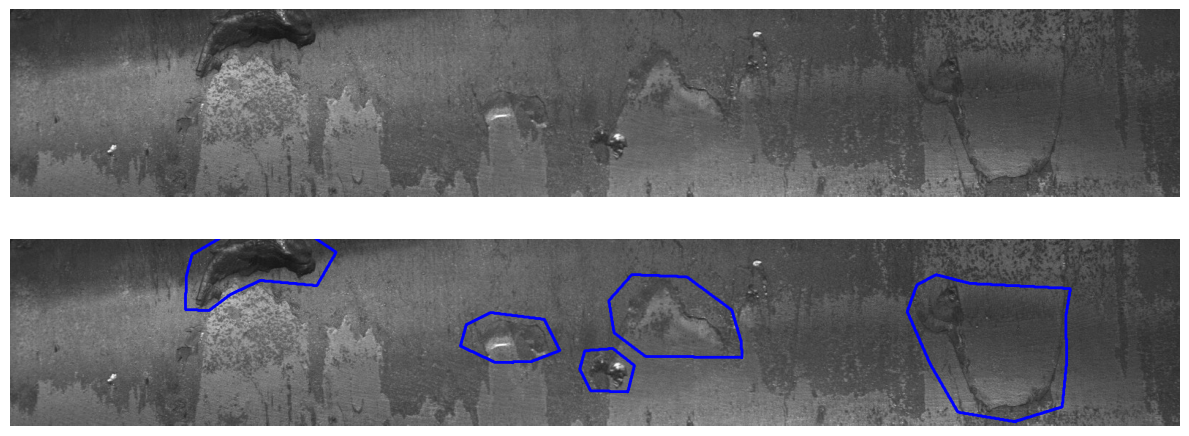

In [17]:
DEFECT = 4


if DEFECT == 1:
    contour_color = "red"
elif DEFECT == 2:
    contour_color = "aqua"
elif DEFECT == 3:
    contour_color = "yellow"
elif DEFECT == 4:
    contour_color = "blue"


filtered_df = df[df["ClassId"] == DEFECT]
sampled_row = random.randint(0, len(filtered_df) - 1)

sample = filtered_df.iloc[sampled_row]

img_name = sample["ImageId"]
img_path = f"{PROJECT_FOLDER}/data/raw/train_images/{img_name}"
img = np.array(Image.open(img_path))

rle_string = sample["EncodedPixels"]
mask = rle_to_mask(rle_string, img.shape[:2])

contours = measure.find_contours(mask, 0.5)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].imshow(img)
axes[0].axis("off")

axes[1].imshow(img)
axes[1].axis("off")

for contour in contours:
    axes[1].plot(contour[:, 1], contour[:, 0], linewidth=2, color=contour_color)

plt.tight_layout()
plt.show()

### Defect Area and Bounding Box Analysis

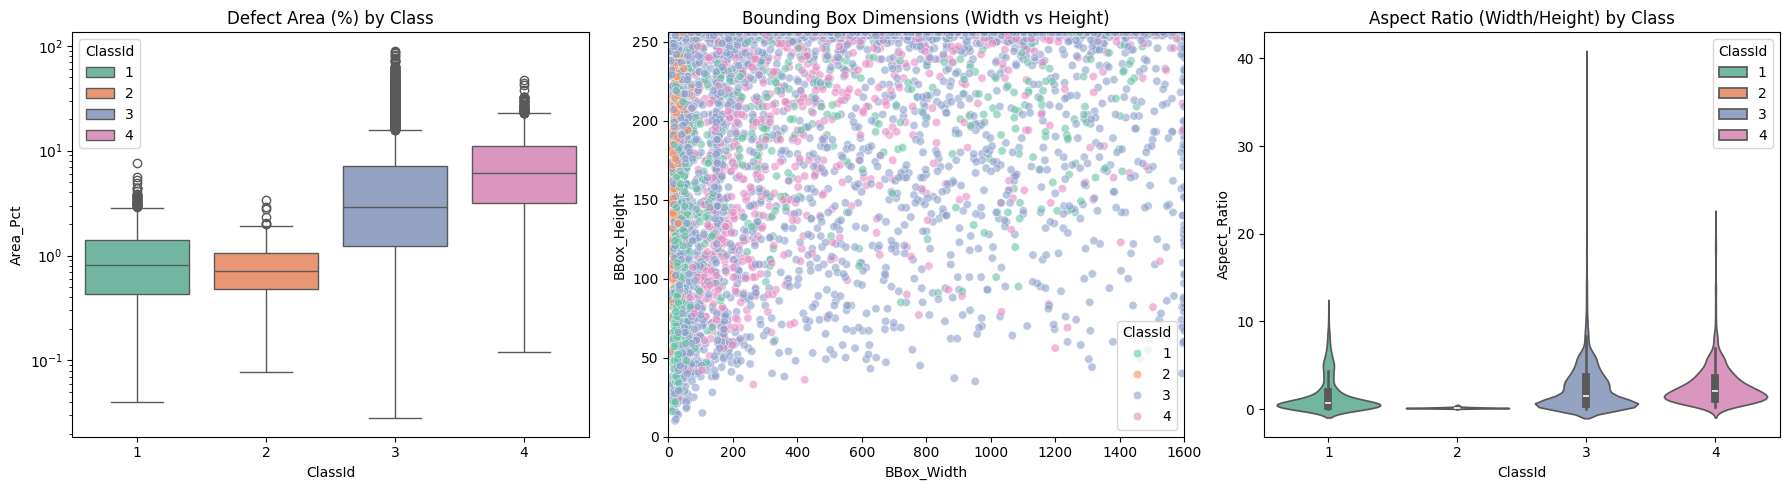

In [21]:
import cv2
import seaborn as sns

# Assuming standard Severstal image shape (Height, Width)
IMG_SHAPE = (256, 1600)
total_pixels = IMG_SHAPE[0] * IMG_SHAPE[1]

# Filter out empty masks (images without defects)
defect_df = df.dropna(subset=["EncodedPixels"]).copy()

areas = []
widths = []
heights = []
aspect_ratios = []
classes = []

for idx, row in defect_df.iterrows():
    mask = rle_to_mask(row["EncodedPixels"], IMG_SHAPE)
    
    # Calculate Area Percentage
    area_pct = (np.sum(mask) / total_pixels) * 100
    
    # Calculate Bounding Box
    # cv2.boundingRect returns (x, y, w, h)
    x, y, w, h = cv2.boundingRect(mask)
    
    areas.append(area_pct)
    widths.append(w)
    heights.append(h)
    # Avoid division by zero just in case
    aspect_ratios.append(w / h if h > 0 else 0)
    classes.append(row["ClassId"])

defect_df["Area_Pct"] = areas
defect_df["BBox_Width"] = widths
defect_df["BBox_Height"] = heights
defect_df["Aspect_Ratio"] = aspect_ratios

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Area Distribution
sns.boxplot(data=defect_df, x="ClassId", y="Area_Pct", hue="ClassId", ax=axes[0], palette="Set2")
axes[0].set_title("Defect Area (%) by Class")
axes[0].set_yscale("log") # Log scale helps visualize tiny defects (Class 1)

# 2. Bounding Box Width vs Height
sns.scatterplot(data=defect_df, x="BBox_Width", y="BBox_Height", hue="ClassId", alpha=0.6, ax=axes[1], palette="Set2")
axes[1].set_title("Bounding Box Dimensions (Width vs Height)")
axes[1].set_xlim(0, 1600)
axes[1].set_ylim(0, 256)

# 3. Aspect Ratio Distribution
sns.violinplot(data=defect_df, x="ClassId", y="Aspect_Ratio", hue="ClassId", ax=axes[2], palette="Set2")
axes[2].set_title("Aspect Ratio (Width/Height) by Class")

plt.tight_layout()
plt.show()

### Defect Co-occurrence Matrix

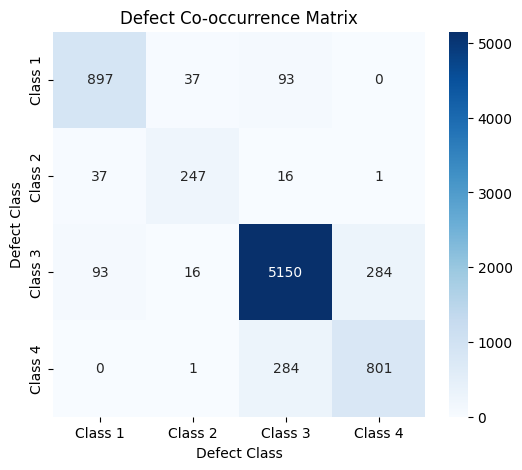

In [19]:
# Group by ImageId and collect all unique ClassIds present in that image
co_occurrence_df = defect_df.groupby("ImageId")["ClassId"].apply(list).reset_index()

# Initialize a 4x4 matrix for Classes 1 to 4
num_classes = 4
co_matrix = np.zeros((num_classes, num_classes), dtype=int)

for classes_in_img in co_occurrence_df["ClassId"]:
    for i in range(len(classes_in_img)):
        for j in range(len(classes_in_img)):
            # -1 because ClassIds are 1-4, but matrix indices are 0-3
            c1 = int(classes_in_img[i]) - 1
            c2 = int(classes_in_img[j]) - 1
            co_matrix[c1, c2] += 1

# --- Plotting ---
plt.figure(figsize=(6, 5))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Class 1", "Class 2", "Class 3", "Class 4"], 
            yticklabels=["Class 1", "Class 2", "Class 3", "Class 4"])
plt.title("Defect Co-occurrence Matrix")
plt.xlabel("Defect Class")
plt.ylabel("Defect Class")
plt.show()

### Spatial Heatmaps of Defect Locations

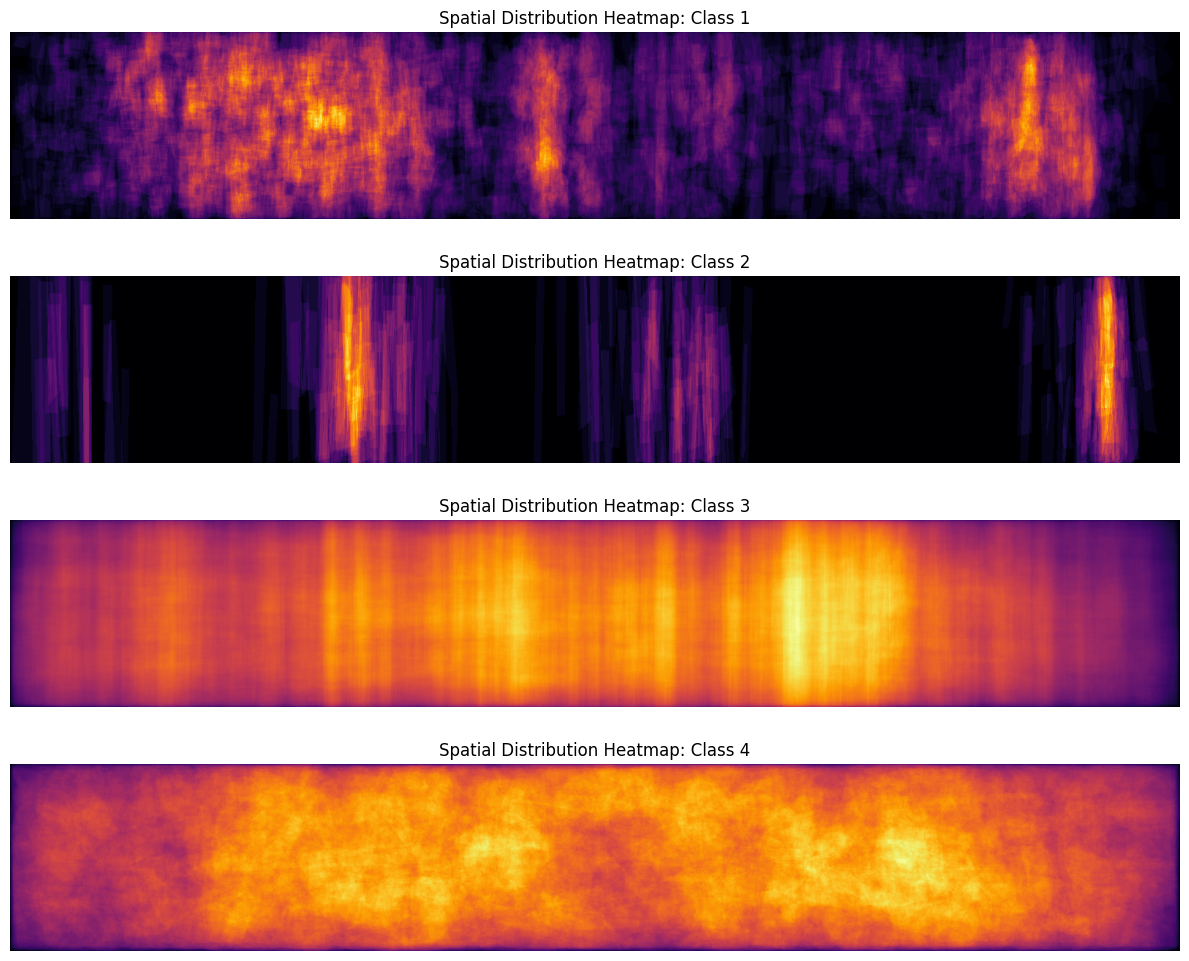

In [23]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

for class_id in range(1, 5):
    # Get all masks for the current class
    class_df = defect_df[defect_df["ClassId"] == class_id]
    
    # Initialize an empty heatmap canvas
    heatmap = np.zeros(IMG_SHAPE, dtype=np.float32)
    
    for rle in class_df["EncodedPixels"]:
        mask = rle_to_mask(rle, IMG_SHAPE)
        heatmap += mask
        
    # Normalize the heatmap for visualization
    if np.max(heatmap) > 0:
        heatmap = heatmap / np.max(heatmap)
    
    ax = axes[class_id - 1]
    # Using 'jet' or 'inferno' colormap for clear hot/cold spots
    im = ax.imshow(heatmap, cmap="inferno")
    ax.set_title(f"Spatial Distribution Heatmap: Class {class_id}")
    ax.axis("off")

plt.tight_layout()
plt.show()